In [201]:
import sys
sys.path.append("..")   # add main_folder to path


from __future__ import annotations
import warnings
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, Iterable
from scipy.stats import gaussian_kde, genextreme
from scipy.ndimage import gaussian_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import tomllib
import pyarrow.dataset as pds
import pyarrow.compute as pc
import pyarrow as pa
import pyarrow.csv as pv
import pyarrow.parquet as pq
from cartopy.feature import NaturalEarthFeature
import math
import warnings

from src.genesis.genesis_utils import read_ibtracs, preprocess_ibtracs

import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
import matplotlib.colors as mcolors

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)

import tarfile
import io

# Visualisation données physiques

In [2]:
dataset = pds.dataset(Path("data/output/catherina_75_seeds/intensified_tracks/ACCESS-CM2/ssp585"), format="parquet", partitioning="hive")
dataset_past = pds.dataset(Path("data/output/catherina_historique_1_seed/intensified_tracks/ACCESS-CM2/historical"), format="parquet", partitioning="hive")

In [3]:
#Helpers
def _wrap_lon(lon: pd.Series | np.ndarray) -> np.ndarray:
    """Wrap longitudes to [-180, 180]."""
    arr = np.asarray(lon, dtype=float)
    arr = ((arr + 180.0) % 360.0) - 180.0
    # Force exactly 180 to be -180 for consistent binning
    arr[arr == 180.0] = -180.0
    return arr

def _as_datetime(x: pd.Series, utc: bool = False) -> pd.Series:
    s = pd.to_datetime(x, errors="coerce")
    if utc:
        try:
            s = s.dt.tz_convert("UTC")  # if timezone-aware
        except Exception:
            s = s.dt.tz_localize("UTC", nonexistent="NaT", ambiguous="NaT")
    return s

def _ensure_sid_generated(df_gen: pd.DataFrame) -> pd.DataFrame:
    """Ensure generated dataframe has a track id column 'SID'."""
    df = df_gen.copy()
    if "SID" in df.columns:
        return df
    if "index" in df.columns:
        df["SID"] = df["index"].astype(str)
    else:
        # Fallback: give everything a single SID (least desirable)
        warnings.warn("No 'SID' or 'index' in generated data. Assigning a single SID.")
        df["SID"] = "GEN_0"
    return df

def _select_cols(df: pd.DataFrame, cols: Iterable[str]) -> pd.DataFrame:
    existing = [c for c in cols if c in df.columns]
    return df[existing].copy()

In [4]:
@dataclass
class GeneratedTracks:
    df: pd.DataFrame

    @classmethod
    def from_df(cls, df: pd.DataFrame) -> "GeneratedTracks":
        expected_some = ['lat_left','lon_left','datetime','basin','wind_speed','pc_hpa',
                         'is_on_land','dist2coast_meters','year','month']
        missing = [c for c in expected_some if c not in df.columns]
        if missing:
            warnings.warn(f"Generated tracks missing commonly used columns: {missing}. Proceeding with what’s available.")

        dd = df.copy()
        dd = _ensure_sid_generated(dd)
        # Time + coords
        if "datetime" in dd.columns:
            dd["datetime"] = _as_datetime(dd["datetime"])
        elif "time" in dd.columns:
            dd["datetime"] = _as_datetime(dd["time"])
        else:
            raise ValueError("Generated tracks need a datetime column ('datetime' or 'time').")

        lat = dd["lat_left"] if "lat_left" in dd.columns else dd.get("LAT", np.nan)
        lon = dd["lon_left"] if "lon_left" in dd.columns else dd.get("LON", np.nan)

        dd["LAT"] = pd.to_numeric(lat, errors="coerce")
        dd["LON"] = _wrap_lon(pd.to_numeric(lon, errors="coerce"))

        # Intensity
        if "wind_speed" in dd.columns:
            dd["wind"] = pd.to_numeric(dd["wind_speed"], errors="coerce")
        if "pc_hpa" in dd.columns:
            dd["pres"] = pd.to_numeric(dd["pc_hpa"], errors="coerce")
        elif "mslp_hpa" in dd.columns:
            dd["pres"] = pd.to_numeric(dd["mslp_hpa"], errors="coerce")

        # Basin naming consistency
        if "basin" in dd.columns:
            dd["BASIN"] = dd["basin"].astype(str)
        elif "BASIN" not in dd.columns:
            dd["BASIN"] = "UNKNOWN"

        # Sort & genesis
        dd.sort_values(["SID", "datetime"], inplace=True, kind="mergesort")
        genesis_idx = dd.groupby("SID", sort=False)["datetime"].idxmin()
        dd["is_genesis"] = False
        dd.loc[genesis_idx, "is_genesis"] = True

        # Landfall events: first time step that transitions offshore -> on_land
        if "is_on_land" in dd.columns:
            dd["is_on_land"] = dd["is_on_land"].astype(bool)
            dd["prev_on_land"] = dd.groupby("SID")["is_on_land"].shift(1).fillna(False)
            dd["is_landfall"] = (~dd["prev_on_land"]) & (dd["is_on_land"])
        else:
            # Fallback: use coastline distance
            if "dist2coast_meters" in dd.columns:
                d = pd.to_numeric(dd["dist2coast_meters"], errors="coerce")
                prev = d.groupby(dd["SID"]).shift(1)
                dd["is_landfall"] = (prev > 0) & (d <= 0)
            else:
                warnings.warn("No land indicator in generated data; landfall charts will be skipped.")
                dd["is_landfall"] = False

        # Lifetime in hours
        life_hours = (dd.groupby("SID")["datetime"].transform("max") -
                      dd.groupby("SID")["datetime"].transform("min")).dt.total_seconds() / 3600.0
        dd["lifetime_hours"] = life_hours

        return cls(dd)

In [5]:
@dataclass
class IBTracks:
    df: pd.DataFrame

    @classmethod
    def from_df(cls, df: pd.DataFrame) -> "IBTracks":
        expected = ['SID','datetime','NAME','LAT','LON','BASIN',
                    'DIST2LAND','LANDFALL','wind','pres']
        missing = [c for c in expected if c not in df.columns]
        if missing:
            raise ValueError(f"IBTrACS missing columns: {missing}")

        dd = df.copy()
        dd["LAT"] = pd.to_numeric(dd["LAT"], errors="coerce")
        dd["LON"] = _wrap_lon(pd.to_numeric(dd["LON"], errors="coerce"))
        dd["wind"] = pd.to_numeric(dd["wind"], errors="coerce")  # kt or m/s? (use consistent unit across both)
        dd["pres"] = pd.to_numeric(dd["pres"], errors="coerce")
        dd["LANDFALL"] = dd["LANDFALL"].astype(str)

        # Genesis: first timestamp per SID
        dd.sort_values(["SID", "datetime"], inplace=True, kind="mergesort")
        genesis_idx = dd.groupby("SID", sort=False)["datetime"].idxmin()
        dd["is_genesis"] = False
        dd.loc[genesis_idx, "is_genesis"] = True

        # Landfall events per IB rule: LANDFALL == "0" marks "within next 6h"
        dd["is_landfall"] = dd["LANDFALL"].eq("0")

        # Lifetime in hours (per SID)
        life_hours = (dd.groupby("SID")["datetime"].transform("max") -
                      dd.groupby("SID")["datetime"].transform("min")).dt.total_seconds() / 3600.0
        dd["lifetime_hours"] = life_hours

        return cls(dd)

In [6]:
def intensity_distributions(gen: GeneratedTracks,
                            savepath: Optional[str] = None):
    """PDF/CDF of max wind and min pressure per storm."""
    def _storm_extremes(df):
        grp = df.groupby("SID", sort=False)
        max_wind = grp["wind"].max()
        min_pres = grp["pres"].min()
        return max_wind, min_pres

    # ib_w, ib_p = _storm_extremes(ib.df)
    ge_w, ge_p = _storm_extremes(gen.df)

    fig, axs = plt.subplots(2, 2, figsize=(10,6), constrained_layout=True)
    # PDFs
    # axs[0,0].hist(ib_w.dropna(), bins=30, density=True, alpha=0.6, label="IBTrACS")
    axs[0,0].hist(ge_w.dropna(), bins=30, density=True, alpha=0.6, label="Generated")
    axs[0,0].set_title("Max Wind PDF"); axs[0,0].set_xlabel("Wind"); axs[0,0].set_ylabel("Density"); axs[0,0].legend()

    # axs[0,1].hist(ib_p.dropna(), bins=30, density=True, alpha=0.6, label="IBTrACS")
    axs[0,1].hist(ge_p.dropna(), bins=30, density=True, alpha=0.6, label="Generated")
    axs[0,1].set_title("Min Pressure PDF"); axs[0,1].set_xlabel("Pressure (hPa)"); axs[0,1].set_ylabel("Density"); axs[0,1].legend()
    # CDFs
    for ax, series, title in [(axs[1,0], ge_w.dropna().sort_values(), "Max Wind CDF (Generated)")]:
        y = np.linspace(0,1,len(series), endpoint=False)
        ax.plot(series.values, y, label=title.split(" (")[1][:-1])
    axs[1,0].set_title("Max Wind CDF"); axs[1,0].set_xlabel("Wind"); axs[1,0].set_ylabel("F"); axs[1,0].legend()

    for ax, series, title in [(axs[1,1], ge_p.dropna().sort_values(), "Min Pres CDF (Generated)")]:
        y = np.linspace(0,1,len(series), endpoint=False)
        ax.plot(series.values, y, label=title.split(" (")[1][:-1])
    axs[1,1].set_title("Min Pressure CDF"); axs[1,1].set_xlabel("Pressure (hPa)"); axs[1,1].set_ylabel("F"); axs[1,1].legend()

    if savepath:
        fig.savefig(savepath, dpi=200)
    return fig

In [7]:
dataset_reduit = dataset.filter(pds.field("seed") == 3)
table = dataset_reduit.to_table()
df = table.to_pandas()

In [8]:
dataset_past_reduit = dataset_past.filter(pds.field("seed") == 0)
table_past = dataset_past_reduit.to_table()
df_past = table_past.to_pandas()

In [9]:
df_tracks = GeneratedTracks.from_df(df.reset_index())

/tmp/ipykernel_5409/2177469986.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dd["prev_on_land"] = dd.groupby("SID")["is_on_land"].shift(1).fillna(False)


In [10]:
df_past

index   lat_left    lon_left            datetime  \
seed SID        step                                                     
0    2917498192 0         0  12.500484 -106.500000 1980-10-01 00:00:00   
                1         1  12.461908 -106.572353 1980-10-01 03:00:00   
                2         2  12.434372 -106.662559 1980-10-01 06:00:00   
                3         3  12.417464 -106.769879 1980-10-01 09:00:00   
                4         4  12.410696 -106.893604 1980-10-01 12:00:00   
...                     ...        ...         ...                 ...   
     2917500698 170     861  27.319018   82.232100 2014-09-22 06:00:00   
                171     862  27.339036   82.297992 2014-09-22 09:00:00   
                172     863  27.360658   82.363217 2014-09-22 12:00:00   
                173     864  27.383792   82.427812 2014-09-22 15:00:00   
                174     865  27.408352   82.491815 2014-09-22 18:00:00   

                                    time    y     x      nshr     mslp_hpa  \
seed SID        step                                                         
0    2917498192 0    1980-10-16 12:00:00  410   294  0.804011  1009.208154   
                1    1980-10-16 12:00:00  409   293  0.817701  1009.189794   
                2    1980-10-16 12:00:00  409   293  0.817701  1009.189794   
                3    1980-10-16 12:00:00  409   292  0.820750  1009.197272   
                4    1980-10-16 12:00:00  409   292  0.820750  1009.197272   
...                                  ...  ...   ...       ...          ...   
     2917500698 170  2014-09-16 00:00:00  469  1048  0.871923  1002.066881   
                171  2014-09-16 00:00:00  469  1049  0.871923  1002.066881   
                172  2014-09-16 00:00:00  469  1049  0.871923  1002.066881   
                173  2014-09-16 00:00:00  469  1049  0.871923  1002.066881   
                174  2014-09-16 00:00:00  469  1049  0.871923  1002.066881   

                         T_strat  ...  t_L_steps_1  pc_hpa_1_eff         qc  \
seed SID        step              ...                                         
0    2917498192 0     265.639008  ...          NaN           NaN        NaN   
                1     265.948730  ...          NaN    997.555092  24.234613   
                2     265.948730  ...          NaN    997.555092  24.234613   
                3     265.935059  ...          NaN    998.785319  24.204763   
                4     265.935059  ...          NaN   1000.102075  24.172894   
...                          ...  ...          ...           ...        ...   
     2917500698 170   262.727783  ...          NaN    951.445889  27.785881   
                171   262.727783  ...          NaN    949.269199  27.849594   
                172   262.727783  ...          NaN    948.944196  27.859132   
                173   262.727783  ...          NaN    945.692045  27.954938   
                174   262.727783  ...          NaN    943.472411  28.020705   

                          delta_Sm         X     MPI_hpa     mpd_hpa  \
seed SID        step                                                   
0    2917498192 0              NaN       NaN         NaN         NaN   
                1     12619.995394  0.016524  992.651248  115.740411   
                2     12619.995394  0.016527  992.648165  115.740411   
                3     12257.094674  0.016039  993.139452  115.740411   
                4     12063.351300  0.015775  993.401665  115.740411   
...                            ...       ...         ...         ...   
     2917500698 170   16467.763432  0.022024  980.238894   89.971853   
                171   16826.372347  0.022569  979.704507   89.971853   
                172   16880.018457  0.022647  979.628561   89.971853   
                173   17418.294948  0.023467  978.825581   89.971853   
                174   17787.213927  0.024027  978.277479   89.971853   

                      mslp_mpd_diff_hpa  year  month  
seed SID        step    

In [11]:
df_past_tracks = IBTracks.from_df(df_past.reset_index())

ValueError: IBTrACS missing columns: ['NAME', 'LAT', 'LON', 'BASIN', 'DIST2LAND', 'LANDFALL', 'wind', 'pres']

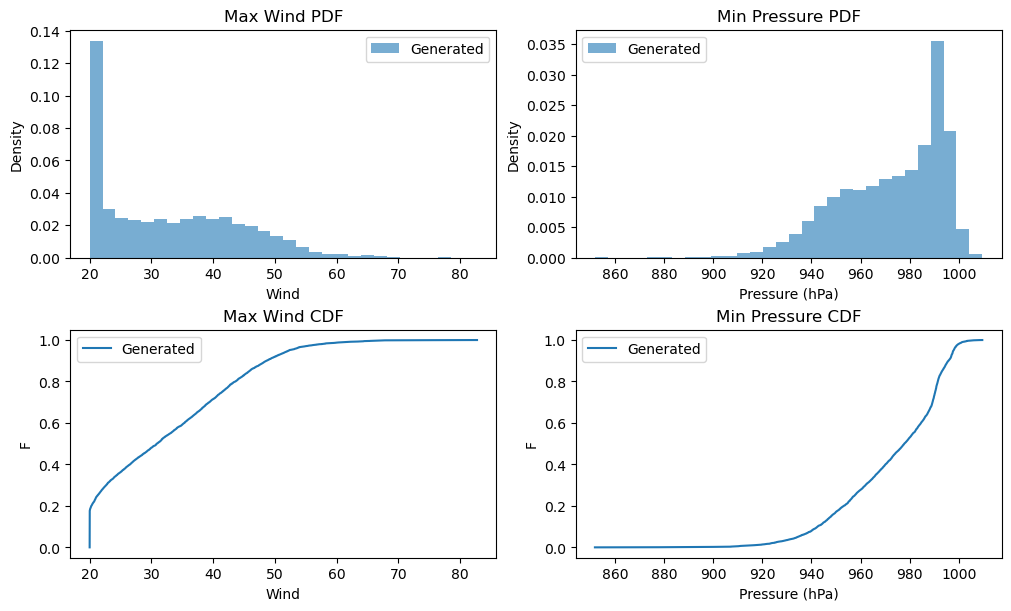

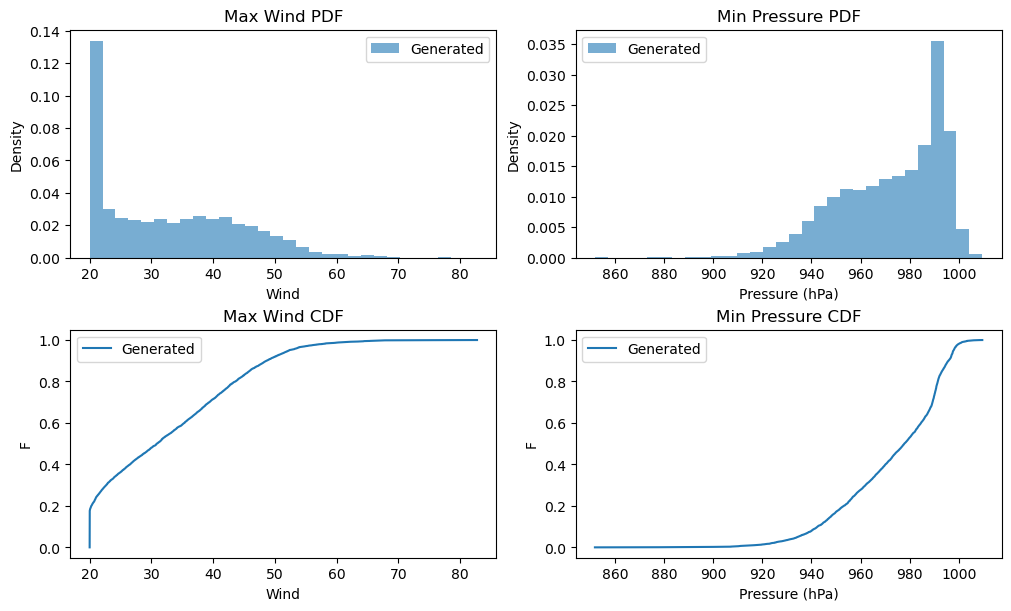

In [ ]:
intensity_distributions(df_tracks)

In [ ]:
# ça a tourné sur données historique, on veut maintenant comparer données historiques et simulées 

# Test analyse données outputs

## Genesis

In [128]:
dataset = pds.dataset(Path("data/output/catherina_20_seeds/genesis/seed=0"), format="parquet", partitioning="hive")

In [129]:
print(dataset.schema)
print("--------------------------")
print(dataset.schema.names)
print("--------------------------")
print(len(dataset.files))

year: int64
month: int64
SID: int64
lat: double
lon: double
basin: string
-- schema metadata --
pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 1009
--------------------------
['year', 'month', 'SID', 'lat', 'lon', 'basin']
--------------------------
6


In [130]:
fragments = list(dataset.get_fragments())
len(fragments)

6

In [131]:
table_EP = dataset.to_table(
    filter=pc.field("basin") == "EP"
)

In [132]:
EP_basin = table_EP.to_pandas()

In [133]:
EP_basin[EP_basin.year==2030]

,year,month,SID,lat,lon,basin
74,2030,5,3496655168,8.500326,-155.5,EP
75,2030,6,3496655170,11.500444,-103.5,EP
76,2030,7,3496655175,14.500564,-106.5,EP
77,2030,7,3496655176,12.500484,-108.5,EP
78,2030,7,3496655177,14.500564,-116.5,EP
79,2030,7,3496655178,7.500287,-91.5,EP
80,2030,7,3496655179,11.500444,-94.5,EP
81,2030,7,3496655180,14.500564,-103.5,EP
82,2030,8,3496655184,16.500646,-104.5,EP
83,2030,9,3496655191,13.500524,-99.5,EP


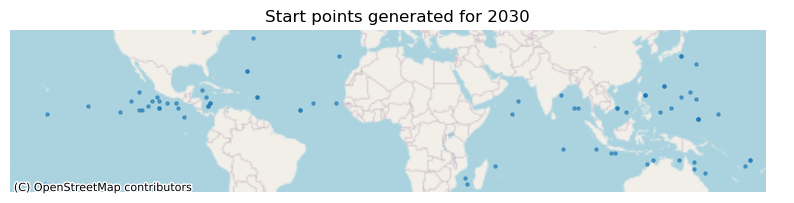

In [145]:
table_2030 = dataset.to_table(
    filter=pc.field("year") == 2030
).to_pandas()

gdf = gpd.GeoDataFrame(
    table_2030,
    geometry=gpd.points_from_xy(table_2030.lon, table_2030.lat),
    crs="EPSG:4326"
)

gdf_3857 = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 16))

# Points
gdf_3857.plot(
    ax=ax,
    markersize=5,
    alpha=0.6,
)

# Fond de carte
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title("Start points generated for 2030")
ax.set_axis_off()

plt.show()

## Track

In [35]:
dataset = pds.dataset(Path("data/output/catherina_20_seeds/track/seed=0"), format="parquet", partitioning="hive")

In [36]:
print(dataset.schema)
print("--------------------------")
print(dataset.schema.names)
print("--------------------------")
print(len(dataset.files))

SID: int64
step: int64
lat: double
lon: double
datetime: timestamp[ns]
__index_level_0__: int64
year: int32
month: int32
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 1199
--------------------------
['SID', 'step', 'lat', 'lon', 'datetime', '__index_level_0__', 'year', 'month']
--------------------------
895


In [41]:
table_2030 = dataset.to_table(
    filter=pc.field("year") == 2030
).to_pandas()

In [42]:
table_2030

coord,SID,step,lat,lon,datetime,year,month
61425,3496655155,0,-23.500949,40.500000,2030-01-01 00:00:00,2030,1
61426,3496655155,1,-23.677722,40.415031,2030-01-01 03:00:00,2030,1
61512,3496655155,2,-23.899266,40.343763,2030-01-01 06:00:00,2030,1
61523,3496655155,3,-24.157043,40.285326,2030-01-01 09:00:00,2030,1
61534,3496655155,4,-24.443762,40.238904,2030-01-01 12:00:00,2030,1
...,...,...,...,...,...,...,...
70780,3496655208,170,NaN,NaN,2030-09-22 06:00:00,2030,9
70781,3496655208,171,NaN,NaN,2030-09-22 09:00:00,2030,9
70782,3496655208,172,NaN,NaN,2030-09-22 12:00:00,2030,9
70783,3496655208,173,NaN,NaN,2030-09-22 15:00:00,2030,9


In [56]:
gdf = gpd.GeoDataFrame(
    table_2030,
    geometry=gpd.points_from_xy(table_2030.lon, table_2030.lat),
    crs="EPSG:4326"
)

gdf_3857 = gdf.to_crs(epsg=3857)

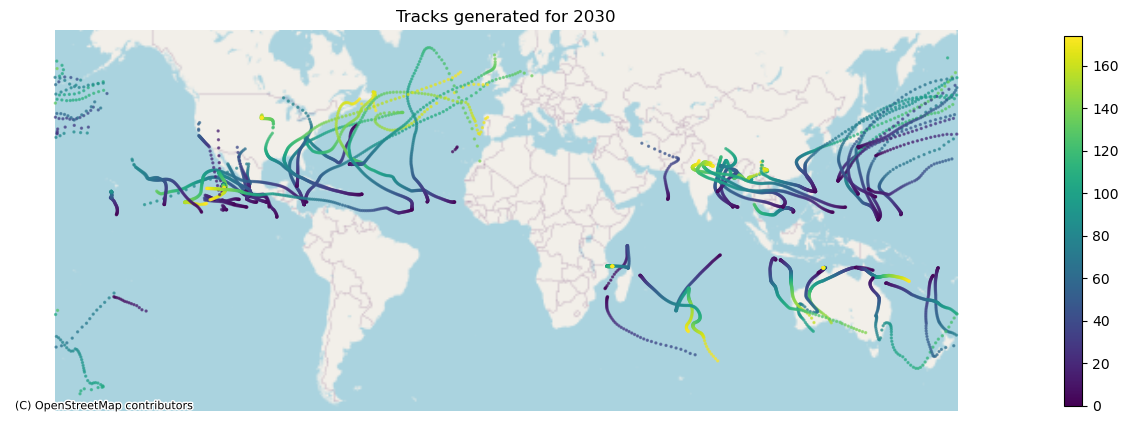

In [85]:
fig, ax = plt.subplots(figsize=(16, 16))

# Points
gdf_3857.plot(
    ax=ax,
    column="step",
    cmap="viridis",
    markersize=2,
    alpha=0.6,
    legend=True,
    legend_kwds={'shrink': 0.3}
)

# Fond de carte
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title("Tracks generated for 2030")
ax.set_axis_off()

plt.show()

In [46]:
table_2030[table_2030.SID == 3496655155].head(50)

coord,SID,step,lat,lon,datetime,year,month
61425,3496655155,0,-23.500949,40.500000,2030-01-01 00:00:00,2030,1
61426,3496655155,1,-23.677722,40.415031,2030-01-01 03:00:00,2030,1
61512,3496655155,2,-23.899266,40.343763,2030-01-01 06:00:00,2030,1
61523,3496655155,3,-24.157043,40.285326,2030-01-01 09:00:00,2030,1
61534,3496655155,4,-24.443762,40.238904,2030-01-01 12:00:00,2030,1
61545,3496655155,5,-24.753217,40.203734,2030-01-01 15:00:00,2030,1
61556,3496655155,6,-25.080147,40.179100,2030-01-01 18:00:00,2030,1
61567,3496655155,7,-25.420114,40.164333,2030-01-01 21:00:00,2030,1
61578,3496655155,8,-25.769392,40.158805,2030-01-02 00:00:00,2030,1
61589,3496655155,9,-26.124868,40.161930,2030-01-02 03:00:00,2030,1


## Track with env

In [86]:
dataset = pds.dataset(Path("data/output/catherina_20_seeds/track_with_env/ACCESS-CM2/ssp585/seed=0"), format="parquet", partitioning="hive")

In [87]:
print(dataset.schema)
print("--------------------------")
print(dataset.schema.names)
print("--------------------------")
print(len(dataset.files))

SID: int64
step: int64
lat_left: double
lon_left: double
datetime: timestamp[ns]
time: timestamp[ns]
y: int64
x: int64
hur: float
psl: float
ta: float
tos: float
height: double
lat_right: double
lon_right: double
distance_track_env: double
__index_level_0__: int64
year: int32
month: int32
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 2442
--------------------------
['SID', 'step', 'lat_left', 'lon_left', 'datetime', 'time', 'y', 'x', 'hur', 'psl', 'ta', 'tos', 'height', 'lat_right', 'lon_right', 'distance_track_env', '__index_level_0__', 'year', 'month']
--------------------------
883


In [88]:
table_2030 = dataset.to_table(
    filter=pc.field("year") == 2030
).to_pandas()

In [92]:
table_2030

,SID,step,lat_left,lon_left,datetime,time,y,x,hur,psl,ta,tos,height,lat_right,lon_right,distance_track_env,year,month
0,3496655155,0,-23.500949,40.500000,2030-01-01 00:00:00,2030-01-16 12:00:00,265,881,81.484375,100795.062500,262.094482,28.986809,2.0,-23.625,40.375,20508.390400,2030,1
1,3496655155,1,-23.677722,40.415031,2030-01-01 03:00:00,2030-01-16 12:00:00,265,881,81.484375,100795.062500,262.094482,28.986809,2.0,-23.625,40.375,7804.476423,2030,1
2,3496655155,2,-23.899266,40.343763,2030-01-01 06:00:00,2030-01-16 12:00:00,264,881,83.995331,100849.265625,262.314911,28.986809,2.0,-23.875,40.375,4562.808266,2030,1
3,3496655155,3,-24.157043,40.285326,2030-01-01 09:00:00,2030-01-16 12:00:00,263,881,84.023438,100849.875000,262.317383,28.717402,2.0,-24.125,40.375,10720.470119,2030,1
4,3496655155,4,-24.443762,40.238904,2030-01-01 12:00:00,2030-01-16 12:00:00,262,880,84.023438,100849.875000,262.317383,28.430462,2.0,-24.375,40.125,15213.015989,2030,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,3496655208,80,51.027092,191.480539,2030-09-11 00:00:00,2030-09-16 00:00:00,564,45,81.421875,101355.687500,258.075928,12.373047,2.0,51.125,-168.625,20951.272694,2030,9
1772,3496655208,81,51.478726,193.275752,2030-09-11 03:00:00,2030-09-16 00:00:00,565,53,83.970612,101303.250000,257.955719,12.427633,2.0,51.375,-166.625,21564.139218,2030,9
1773,3496655208,82,51.682646,195.193567,2030-09-11 06:00:00,2030-09-16 00:00:00,566,60,84.210938,101322.312500,258.053223,12.201040,2.0,51.625,-164.875,12854.741279,2030,9
1774,3496655208,83,51.846120,197.208652,2030-09-11 09:00:00,2030-09-16 00:00:00,567,68,84.218750,101330.125000,258.146240,12.240680,2.0,51.875,-162.875,10668.302860,2030,9


In [96]:
gdf = gpd.GeoDataFrame(
    table_2030,
    geometry=gpd.points_from_xy(table_2030.lon_right, table_2030.lat_right),
    crs="EPSG:4326"
)

gdf_3857 = gdf.to_crs(epsg=3857)

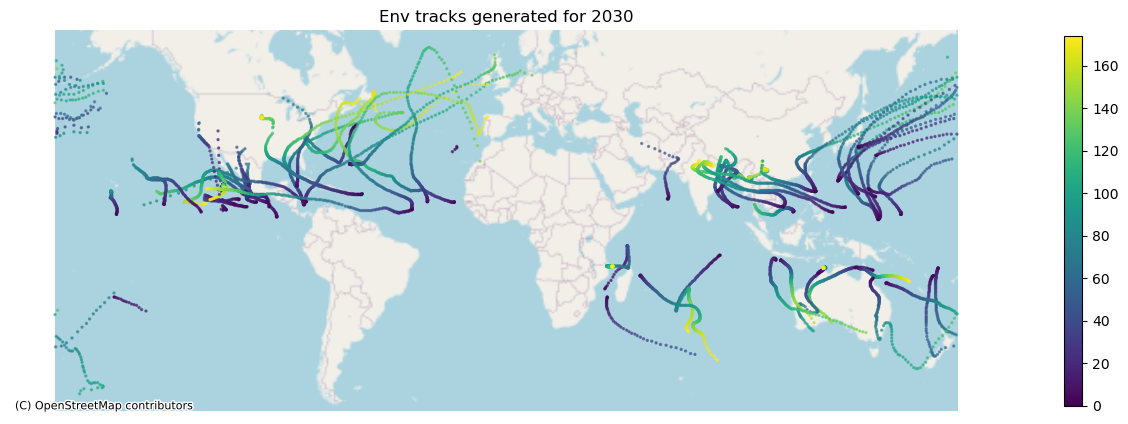

In [98]:
fig, ax = plt.subplots(figsize=(16, 16))

# Points
gdf_3857.plot(
    ax=ax,
    column="step",
    cmap="viridis",
    markersize=2,
    alpha=0.6,
    legend=True,
    legend_kwds={'shrink': 0.3}
)

# Fond de carte
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title("Env tracks generated for 2030")
ax.set_axis_off()

plt.show()

## Tracks with env corrected

In [99]:
dataset = pds.dataset(Path("data/output/catherina_20_seeds/track_with_env_corr/ACCESS-CM2/ssp585/ACCESS-CM2/ssp585/seed=0"), format="parquet", partitioning="hive")

In [100]:
table_2030 = dataset.to_table(
    filter=pc.field("year") == 2030
).to_pandas()

In [102]:
table_2030.columns

Index(['SID', 'step', 'lat_left', 'lon_left', 'datetime', 'time', 'y', 'x',
       'nshr', 'MSLP', 'T_strat', 'SST', 'height', 'lat_right', 'lon_right',
       'distance_track_env', 'thermo_eff', 'year', 'month'],
      dtype='object')

In [104]:
table_2030

,SID,step,lat_left,lon_left,datetime,time,y,x,nshr,MSLP,T_strat,SST,height,lat_right,lon_right,distance_track_env,thermo_eff,year,month
0,3496655155,0,-23.500949,40.500000,2030-01-01 00:00:00,2030-01-16 12:00:00,265,881,0.872123,1007.368299,262.094482,28.986809,2.0,-23.625,40.375,20508.390400,0.313298,2030,1
1,3496655155,1,-23.677722,40.415031,2030-01-01 03:00:00,2030-01-16 12:00:00,265,881,0.872123,1007.368299,262.094482,28.986809,2.0,-23.625,40.375,7804.476423,0.313298,2030,1
2,3496655155,2,-23.899266,40.343763,2030-01-01 06:00:00,2030-01-16 12:00:00,264,881,0.880656,1007.645207,262.314911,28.986809,2.0,-23.875,40.375,4562.808266,0.311503,2030,1
3,3496655155,3,-24.157043,40.285326,2030-01-01 09:00:00,2030-01-16 12:00:00,263,881,0.880716,1007.650539,262.317383,28.717402,2.0,-24.125,40.375,10720.470119,0.310531,2030,1
4,3496655155,4,-24.443762,40.238904,2030-01-01 12:00:00,2030-01-16 12:00:00,262,880,0.880716,1007.650539,262.317383,28.430462,2.0,-24.375,40.125,15213.015989,0.308522,2030,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1771,3496655208,80,51.027092,191.480539,2030-09-11 00:00:00,2030-09-16 00:00:00,564,45,0.871968,1011.697996,258.075928,12.373047,2.0,51.125,-168.625,20951.272694,0.239944,2030,9
1772,3496655208,81,51.478726,193.275752,2030-09-11 03:00:00,2030-09-16 00:00:00,565,53,0.880606,1011.055571,257.955719,12.427633,2.0,51.375,-166.625,21564.139218,0.240413,2030,9
1773,3496655208,82,51.682646,195.193567,2030-09-11 06:00:00,2030-09-16 00:00:00,566,60,0.881078,1011.237953,258.053223,12.201040,2.0,51.625,-164.875,12854.741279,0.239126,2030,9
1774,3496655208,83,51.846120,197.208652,2030-09-11 09:00:00,2030-09-16 00:00:00,567,68,0.881091,1011.414016,258.146240,12.240680,2.0,51.875,-162.875,10668.302860,0.238677,2030,9


In [161]:
import json

In [163]:
queries

[{'ACCESS-CM2': {'institution_id': 'CSIRO-ARCCSS',
   'member_id': 'r1i1p1f1',
   'experiment_id': 'historical'},
  'MIROC-ES2L': {'institution_id': 'MIROC',
   'member_id': 'r10i1p1f2',
   'experiment_id': 'historical'},
  'MPI-ESM1-2-LR': {'institution_id': 'MPI-M',
   'member_id': 'r1i1p1f1',
   'experiment_id': 'historical'},
  'UKESM1-0-LL': {'institution_id': 'MOHC',
   'member_id': 'r2i1p1f2',
   'experiment_id': 'historical'},
  'FGOALS_g3': {'institution_id': 'CAS',
   'member_id': 'r2i1p1f1',
   'experiment_id': 'historical'},
  'IPSL-CM6A-LR': {'institution_id': 'IPSL',
   'member_id': 'r6i1p1f1',
   'experiment_id': 'historical'}}]

## Tracks with env + decay

In [153]:
dataset = pds.dataset(Path("data/output/catherina_20_seeds/intensified_tracks/ACCESS-CM2/ssp585/seed=0"), format="parquet", partitioning="hive")

In [154]:
table_2030 = dataset.to_table(
    filter=pc.field("year") == 2030
).to_pandas()

In [155]:
table_2030.columns

Index(['index', 'lat_left', 'lon_left', 'datetime', 'time', 'y', 'x', 'nshr',
       'mslp_hpa', 'T_strat', 'SST', 'height', 'lat_right', 'lon_right',
       'distance_track_env', 'thermo_eff', 'basin', 'A', 'B', 'C', 'a', 'b',
       'c_0', 'c_1', 'c_2', 'c_3', 'sigma_pc', 'q_env', 'wind_speed',
       'delta_pc_hpa', 'pc_hpa', 'eps_pc', 'is_on_land', 'dist2coast_meters',
       'V_0', 't_L_steps', 'final_wind_speed', 'delta_pc_hpa_1', 'pc_hpa_1',
       'final_wind_1', 'final_wind_2', 'V_0_1', 't_L_steps_1', 'pc_hpa_1_eff',
       'qc', 'delta_Sm', 'X', 'MPI_hpa', 'mpd_hpa', 'mslp_mpd_diff_hpa',
       'year', 'month'],
      dtype='object')

In [156]:
table_2030

index   lat_left    lon_left            datetime  \
SID        step                                                     
3496655155 0         0 -23.500949   40.500000 2030-01-01 00:00:00   
           1         1 -23.677722   40.415031 2030-01-01 03:00:00   
           2         2 -23.899266   40.343763 2030-01-01 06:00:00   
           3         3 -24.157043   40.285326 2030-01-01 09:00:00   
           4         4 -24.443762   40.238904 2030-01-01 12:00:00   
...                ...        ...         ...                 ...   
3496655208 51     1742  37.090798  141.802058 2030-09-07 09:00:00   
           52     1743  38.142999  142.867944 2030-09-07 12:00:00   
           53     1744  39.249835  144.048315 2030-09-07 15:00:00   
           54     1745  40.362648  145.293066 2030-09-07 18:00:00   
           55     1746  41.451482  146.597498 2030-09-07 21:00:00   

                               time    y     x      nshr     mslp_hpa  \
SID        step                                                         
3496655155 0    2030-01-16 12:00:00  265   881  0.872123  1007.368299   
           1    2030-01-16 12:00:00  265   881  0.872123  1007.368299   
           2    2030-01-16 12:00:00  264   881  0.880656  1007.645207   
           3    2030-01-16 12:00:00  263   881  0.880716  1007.650539   
           4    2030-01-16 12:00:00  262   880  0.880716  1007.650539   
...                             ...  ...   ...       ...          ...   
3496655208 51   2030-09-16 00:00:00  508  1287  0.815072  1011.054494   
           52   2030-09-16 00:00:00  512  1291  0.790875  1011.149265   
           53   2030-09-16 00:00:00  516  1296  0.790764  1011.609538   
           54   2030-09-16 00:00:00  521  1301  0.800283  1011.749047   
           55   2030-09-16 00:00:00  525  1306  0.882378  1012.272640   

                    T_strat        SST  height  lat_right  lon_right  \
SID        step                                                        
3496655155 0     262.094482  28.986809     2.0    -23.625     40.375   
           1     262.094482  28.986809     2.0    -23.625     40.375   
           2     262.314911  28.986809     2.0    -23.875     40.375   
           3     262.317383  28.717402     2.0    -24.125     40.375   
           4     262.317383  28.430462     2.0    -24.375     40.125   
...                     ...        ...     ...        ...        ...   
3496655208 51    259.453857  24.090496     2.0     37.125    141.875   
           52    259.351318  23.589605     2.0     38.125    142.875   
           53    259.230713  24.076054     2.0     39.125    144.125   
           54    259.070557  23.545982     2.0     40.375    145.375   
           55    258.896179  20.076616     2.0     41.375    146.625   

                 distance_track_env  thermo_eff basin           A           B  \
SID        step                                                                 
3496655155 0           20508.390400    0.313298    SI  250.381619 -154.656429   
           1            7804.476423    0.313298    SI  250.381619 -154.656429   
           2            4562.808266    0.311503    SI  250.381619 -154.656429   
           3           10720.470119    0.310531    SI  250.381619 -154.656429   
           4           15213.015989    0.308522    SI  250.381619 -154.656429   
...                             ...         ...   ...         ...         ...   
3496655208 51           9419.376377    0.298580    WP    6.526186  102.374171   
           52           2665.714310    0.293947    WP    6.526186  102.374171   
           53          19857.651166    0.300689    WP    6.526186  102.374171   
           54           9297.702234    0.297400    WP    6.526186  102.374171   
           55          11758.140395    0.271152    WP    6.526186  102.374171   

                        C         a         b       c_0       c_1       c_2  \
SID        step                                                               
3496655155 0    -0.0

In [157]:
gdf = gpd.GeoDataFrame(
    table_2030.reset_index(),
    geometry=gpd.points_from_xy(table_2030.lon_left, table_2030.lat_left),
    crs="EPSG:4326"
)

gdf_3857 = gdf.to_crs(epsg=3857)

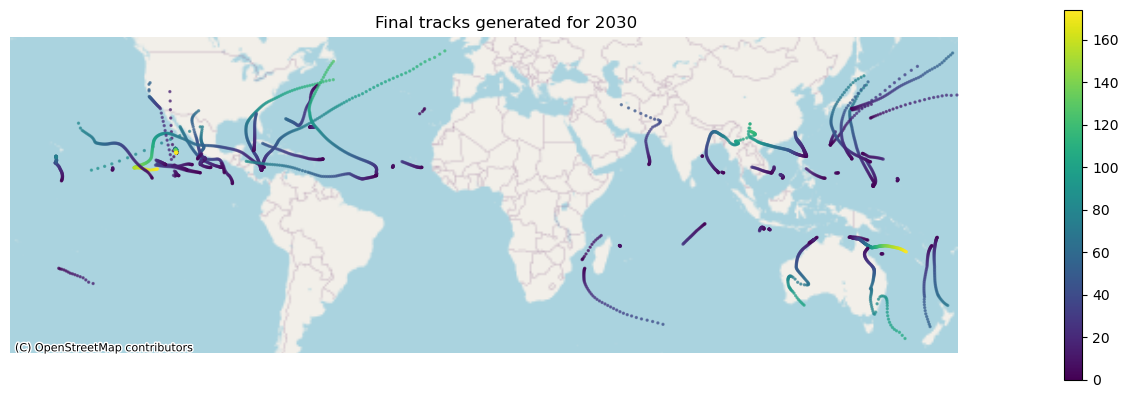

In [160]:
fig, ax = plt.subplots(figsize=(16, 16))

# Points
gdf_3857.plot(
    ax=ax,
    column="step",
    cmap="viridis",
    markersize=2,
    alpha=0.6,
    legend=True,
    legend_kwds={'shrink': 0.3},
)

# Fond de carte
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik
)

ax.set_title("Final tracks generated for 2030")
ax.set_axis_off()

plt.show()

## Litpop

### Norm litpop data

In [167]:
path_litpop = "data/input/wealth_densities/litpop/litpop_full/Lit_Pop_norm_v1.tar"
rows = []
# read the litpop data
with tarfile.open(path_litpop, "r") as tar:
    for member in tar:
        rows.append({
            "name": member.name,
            "size": member.size,
            "type": member.type,
            "mtime": member.mtime,
            "is_file": member.isfile(),
            "is_dir": member.isdir()
        })

litpop_df = pd.DataFrame(rows)

In [168]:
litpop_df

,name,size,type,mtime,is_file,is_dir
0,./._Lit_norm_30arcsec_AUS.csv,278,b'0',1552051722,True,False
1,Lit_norm_30arcsec_AUS.csv,27142304,b'0',1552051722,True,False
2,./._Lit_norm_30arcsec_BRA.csv,244,b'0',1552046109,True,False
3,Lit_norm_30arcsec_BRA.csv,27261045,b'0',1552046109,True,False
4,./._Lit_norm_30arcsec_CAN.csv,244,b'0',1552046562,True,False
5,Lit_norm_30arcsec_CAN.csv,901051326,b'0',1552046562,True,False
6,./._Lit_norm_30arcsec_CHE.csv,244,b'0',1552045782,True,False
7,Lit_norm_30arcsec_CHE.csv,2263626,b'0',1552045782,True,False
8,Lit_norm_30arcsec_CHN.csv,548845863,b'0',1552046776,True,False
9,Lit_norm_30arcsec_DEU.csv,31407619,b'0',1552046860,True,False


In [ ]:
"Lit_norm_30arcsec_USA.csv"
"Pop_norm_30arcsec_USA.csv"

In [179]:
with tarfile.open(path_litpop, "r:") as tar:
    member = tar.getmember("Lit_norm_30arcsec_USA.csv")
    f = tar.extractfile(member)
    text_stream = io.TextIOWrapper(f, encoding="utf-8", newline="")
    df_preview = pd.read_csv(text_stream, nrows=1000)

In [180]:
df_preview

,value,latitude,longitude
0,0.0,51.279167,-179.137500
1,0.0,51.270833,-179.137500
2,0.0,51.262500,-179.137500
3,0.0,51.279167,-179.129167
4,0.0,51.270833,-179.129167
...,...,...,...
995,0.0,51.720833,-177.879167
996,0.0,51.712500,-177.879167
997,0.0,51.704167,-177.879167
998,0.0,51.695833,-177.879167


In [181]:
with tarfile.open(path_litpop, "r:") as tar:
    member = tar.getmember("Pop_norm_30arcsec_USA.csv")
    f = tar.extractfile(member)
    text_stream = io.TextIOWrapper(f, encoding="utf-8", newline="")
    df_preview = pd.read_csv(text_stream, nrows=1000)

In [183]:
df_preview.value.unique()

array([0.])

### Full litpop data

In [185]:
path_litpop = "data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2.tar"
rows = []
# read the litpop data
with tarfile.open(path_litpop, "r") as tar:
    for member in tar:
        rows.append({
            "name": member.name,
            "size": member.size,
            "type": member.type,
            "mtime": member.mtime,
            "is_file": member.isfile(),
            "is_dir": member.isdir()
        })

litpop_df = pd.DataFrame(rows)

In [188]:
litpop_df.head(50)

,name,size,type,mtime,is_file,is_dir
0,LitPop_v1_2,0,b'5',1586428289,False,True
1,LitPop_v1_2/LitPop_pc_30arcsec_LTU.csv,7432587,b'0',1551886059,True,False
2,LitPop_v1_2/LitPop_pc_30arcsec_BWA.csv,41742876,b'0',1551884465,True,False
3,LitPop_v1_2/LitPop_pc_30arcsec_IRQ.csv,33980358,b'0',1551885999,True,False
4,LitPop_v1_2/LitPop_pc_30arcsec_MHL.csv,8594,b'0',1551886078,True,False
5,LitPop_v1_2/LitPop_pc_30arcsec_SVN.csv,1925444,b'0',1551886485,True,False
6,LitPop_v1_2/LitPop_pc_30arcsec_STP.csv,70387,b'0',1551886465,True,False
7,LitPop_v1_2/LitPop_pc_30arcsec_DZA.csv,174233767,b'0',1551884402,True,False
8,LitPop_v1_2/LitPop_pc_30arcsec_VGB.csv,10078,b'0',1551886568,True,False
9,LitPop_v1_2/LitPop_pc_30arcsec_MRT.csv,76378495,b'0',1551886086,True,False


In [199]:
litpop_df.loc[litpop_df.name.str.contains("USA")]

,name,size,type,mtime,is_file,is_dir
91,LitPop_v1_2/LitPop_pc_30arcsec_USA.csv,792091920,b'0',1551887122,True,False


In [215]:
path_parquet_USA = "data/input/wealth_densities/litpop/litpop_full/LitPop_v1_2_USA.parquet"

with tarfile.open(path_litpop, "r:") as tar:
    member = tar.getmember("LitPop_v1_2/LitPop_pc_30arcsec_USA.csv")
    f = tar.extractfile(member)

    # Lecteur CSV en streaming
    csv_reader = pv.open_csv(
        f,
        read_options=pv.ReadOptions(block_size=1 << 20),  # ~1 MB par chunk
    )

    # Écriture Parquet incrémentale
    writer = None
    for next_batch in csv_reader:
        table = pa.Table.from_batches([next_batch])

        if writer is None:
            writer = pq.ParquetWriter(
                path_parquet_USA,
                table.schema,
                compression="snappy"
            )

        writer.write_table(table)

    if writer:
        writer.close()

In [216]:
df_usa = pl.read_parquet(path_parquet_USA)

In [217]:
df_usa

value,latitude,longitude,region_id
f64,f64,f64,i64
0.0,51.279167,-179.1375,840
0.0,51.270833,-179.1375,840
0.0,51.2625,-179.1375,840
0.0,51.279167,-179.129167,840
0.0,51.270833,-179.129167,840
…,…,…,…
0.0,51.9625,179.7625,840
0.0,51.954167,179.7625,840
0.0,51.945833,179.7625,840


In [218]:
df_usa.select(pl.col("value")).describe()

statistic,value
str,f64
"""count""",1.6075317e7
"""null_count""",0.0
"""mean""",3.4587e6
"""std""",3.9848e7
"""min""",0.0
"""25%""",0.0
"""50%""",17.878073
"""75%""",2690.270245
"""max""",1.0530e10


In [219]:
df_usa.select(pl.col("value")).sum()

value
f64
5.5599e13


In [ ]:
# Nos données (Denisa)

path_litpop_USA_preprocessed = "data/input/wealth_densities/litpop/5 minutes/LitPop_pc_300_arcsec_USA_v1.hdf5"
df_usa_preprocessed = pd.read_hdf(path_litpop_USA_preprocessed)
print(f"{df_usa_preprocessed.value.sum():.2e}")

In [220]:
df_usa

value,latitude,longitude,region_id
f64,f64,f64,i64
0.0,51.279167,-179.1375,840
0.0,51.270833,-179.1375,840
0.0,51.2625,-179.1375,840
0.0,51.279167,-179.129167,840
0.0,51.270833,-179.129167,840
…,…,…,…
0.0,51.9625,179.7625,840
0.0,51.954167,179.7625,840
0.0,51.945833,179.7625,840
